In [8]:
import warnings
import numpy as np
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
from scipy.special import sph_harm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from scipy.special import eval_legendre
from scipy.integrate import quad

warnings.filterwarnings(
    "ignore",
    message="`scipy.special.sph_harm` is deprecated*",  # match SciPy's exact message
    category=DeprecationWarning
)

In [9]:
# Fibonacci sampling is a way to sample uniform-ish points on a sphere
def fibonacci_sphere(N):
    i = jnp.arange(N)
    ga = jnp.pi * (3 - jnp.sqrt(5.0))
    phi = ga * i
    z = 1 - 2*(i + 0.5)/N
    r = jnp.sqrt(jnp.maximum(0, 1 - z*z))

    x = r * jnp.cos(phi)
    y = r * jnp.sin(phi)

    theta = jnp.arccos(z)         
    phi_mod = phi % (2*jnp.pi)

    X = jnp.stack([x, y, z], axis=1)
    return X.astype(jnp.float32), theta, phi_mod

# Real spherical harmonics for sph_harm, needs normalization and extraction of real part
def real_Ylm(l, m, theta, phi):
    # SciPy sph_harm uses arguments (m, l, phi=azimuth, theta=colatitude)
    Y = sph_harm(m, l, phi, theta)   # complex-valued

    if m > 0:
        return np.sqrt(2) * Y.real
    elif m < 0:
        return np.sqrt(2) * Y.imag
    else:
        return Y.real

# Enumerate spherical harmonic modes (l,m), m is allowed in [-l,l]
def make_lm_list(L_max):
    lm = []
    for l in range(L_max+1):
        for m in range(-l, l+1):
            lm.append((l,m))
    return lm

# Plotting of points on a 3D sphere
def scatter_on_sphere(ax, X, vals, title, vmin, vmax):
    x = np.array(X[:,0])
    y = np.array(X[:,1])
    z = np.array(X[:,2])
    vals = np.array(vals)

    sc = ax.scatter(x, y, z, c=vals, s=8,
                    cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_axis_off()
    ax.view_init(elev=20, azim=-60)
    return sc

def xt_from_t(t):
    # Construct a point whose dot product with x0 is t
    return np.array([[np.sqrt(1.0 - t*t), 0.0, t]])

def kappa(t, kernel_fn):
    xt = xt_from_t(t)
    # Fixed reference point at the north pole
    x0 = np.array([[0.0, 0.0, 1.0]])
    # kernel_fn returns a pytree; extract the scalar NTK value
    val = kernel_fn(x0, xt, 'ntk')
    return float(np.asarray(val)[0, 0])

def mercer_lambda(l, kernel_fn):
    integrand = lambda t: kappa(t, kernel_fn) * eval_legendre(l, t)
    val, _ = quad(integrand, -1.0, 1.0, epsabs=1e-7, epsrel=1e-7)
    return 2*np.pi * val

In [10]:
# Data creation
N_train = 2000
N_test  = 5000

X_train, theta_train, phi_train = fibonacci_sphere(N_train)
X_test,  theta_test,  phi_test  = fibonacci_sphere(N_test)

# Model creation
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1.0, b_std=0.0, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1.0, b_std=0.0, parameterization="ntk")
)

# Compute kernels
kernel_fn = nt.batch(kernel_fn, device_count=-1)
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

L_max=100
lambda_ells=[]

# Mercer spectrum
for l in tqdm(range(L_max+1)):
    lambda_ells.append(mercer_lambda(l, kernel_fn))

lambda_ells = jnp.array(lambda_ells)

# Kernel regression on a range of harmonics as target functions
reg = 1e-12 # You don't really need this, the conditioning number is already good
K_reg = K_train + reg * jnp.eye(N_train)

lm_list = make_lm_list(L_max)
num_modes = len(lm_list)

train_mse = []
test_mse = []

selected_modes = [(0,0), (1,0), (2,-1), (3,2), (4,0), (6,-3), (5,4), (7,5), (50, 2), (70, 3)]
predictions = {}

mode_indices = {(l,m): i for i,(l,m) in enumerate(lm_list)}

for (l,m) in tqdm(lm_list):
    y_train = real_Ylm(l, m, theta_train, phi_train)
    y_test  = real_Ylm(l, m, theta_test,  phi_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_mse.append(jnp.mean((y_pred_train - y_train)**2))
    test_mse.append(jnp.mean((y_pred_test  - y_test)**2))

    if (l,m) in selected_modes:
        predictions[(l,m)] = (y_test, y_pred_test, theta_test, phi_test)

train_mse = jnp.array(train_mse)
test_mse  = jnp.array(test_mse)

100%|██████████| 10201/10201 [01:30<00:00, 112.97it/s]


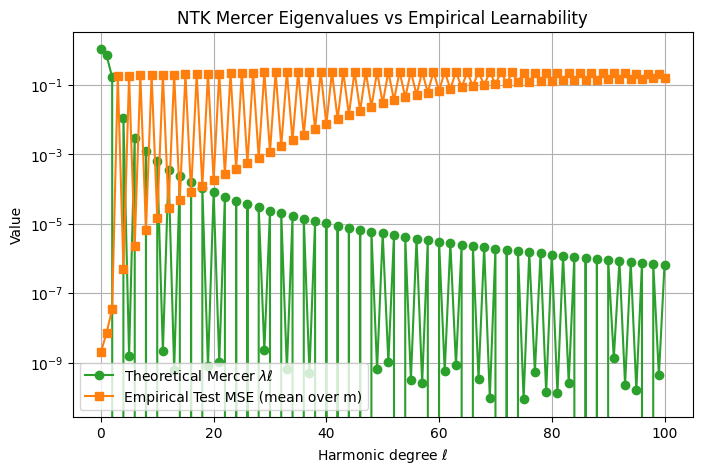

In [11]:
# Mse vs harmonics degree (l)
L_vals = max(l for (l,m) in lm_list)

test_mse_by_l = []
train_mse_by_l = []
for l in range(L_vals+1):
    test_mse_l = [test_mse[mode_indices[(l,m)]] for m in range(-l,l+1)]
    test_mse_by_l.append(jnp.mean(jnp.array(test_mse_l)))
    train_mse_l = [train_mse[mode_indices[(l,m)]] for m in range(-l,l+1)]
    train_mse_by_l.append( jnp.mean(jnp.array(train_mse_l)) )

plt.figure(figsize=(8,5))
plt.semilogy(lambda_ells, 'o-', label=r"Theoretical Mercer $\lambda \ell$", c='C2')
plt.semilogy(test_mse_by_l, 's-', label="Empirical Test MSE (mean over m)", c='C1')
plt.xlabel(r"Harmonic degree $\ell$")
plt.ylabel("Value")
plt.title("NTK Mercer Eigenvalues vs Empirical Learnability")
plt.grid(True)
plt.legend()
plt.show()

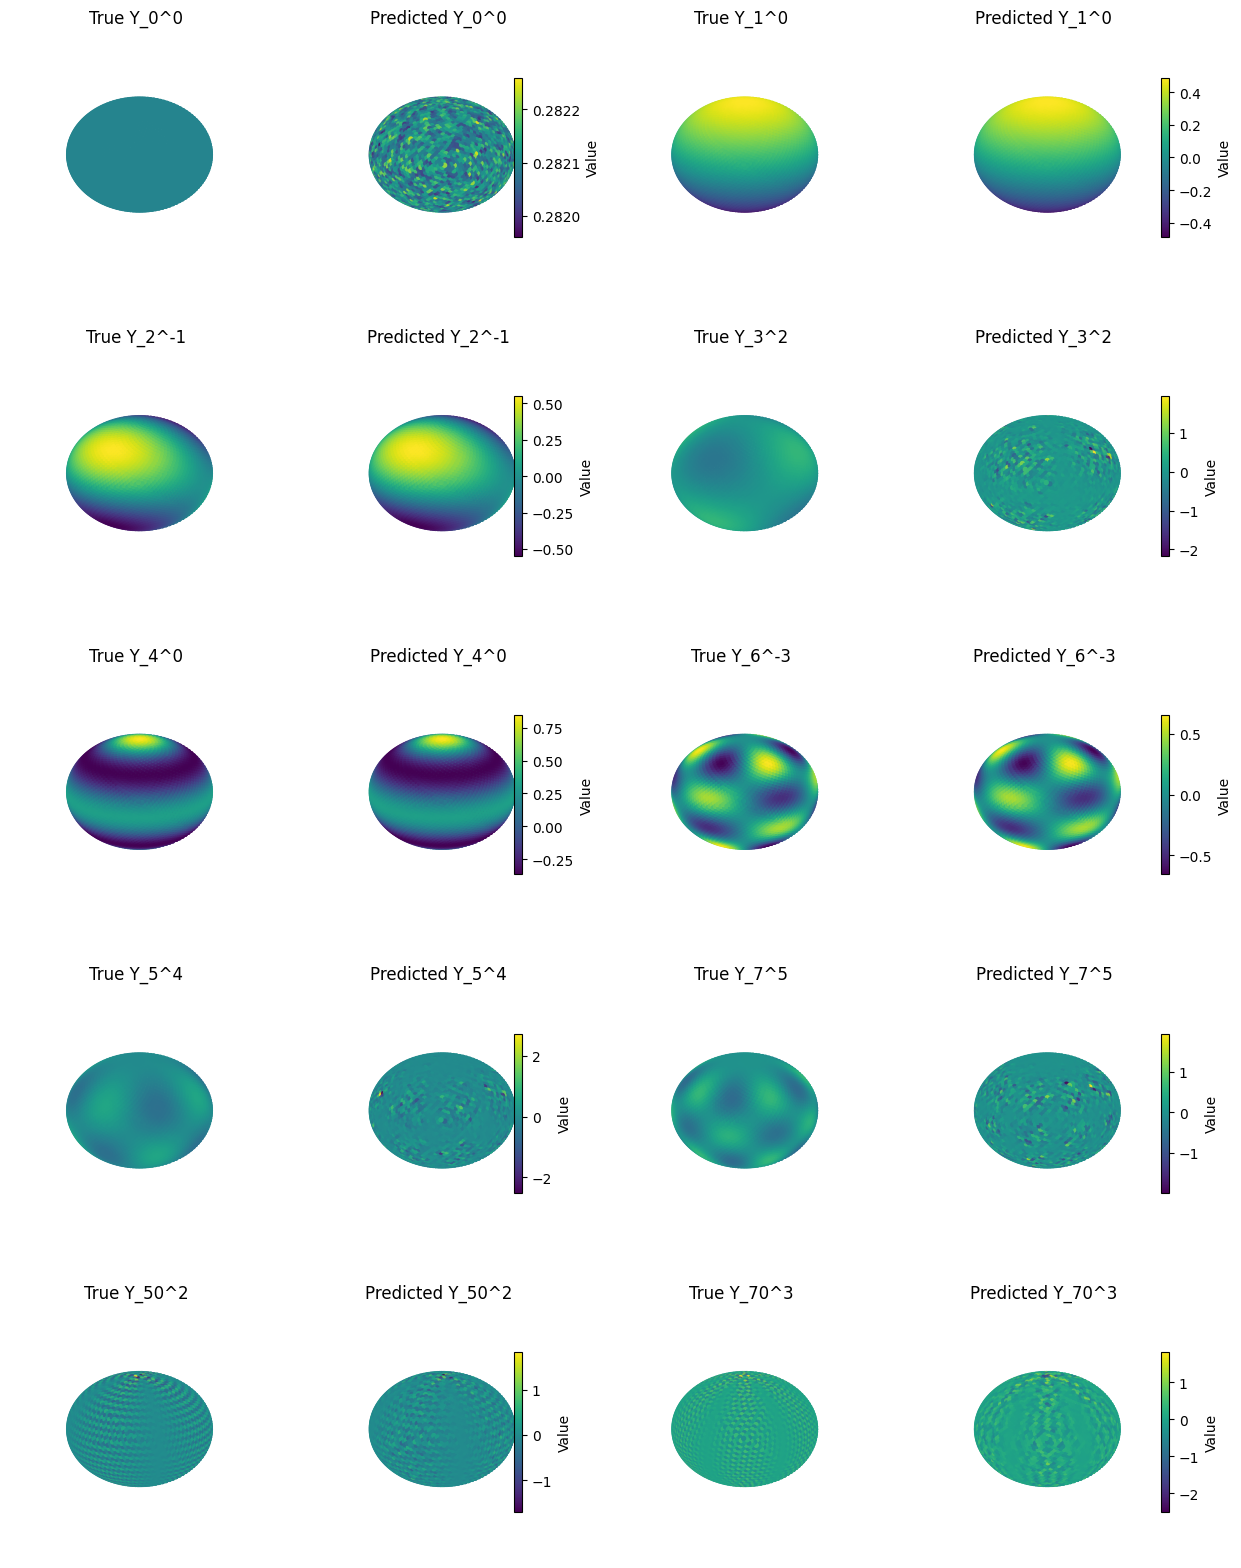

In [12]:
# Show some examples of True harmonics vs predicted harmonics
n_cols = 4
n_rows = int(len(selected_modes)*2/n_cols)

fig = plt.figure(figsize=(16, 4*n_rows))

# For each (l,m), draw two subplots and one colorbar, the amplitudes are different so I can't use a global colorbar
for i, (l,m) in enumerate(selected_modes):
    y_true, y_pred, th, ph = predictions[(l,m)]

    vmin = float(min(y_true.min(), y_pred.min()))
    vmax = float(max(y_true.max(), y_pred.max()))

    ax_true = fig.add_subplot(n_rows, n_cols, 2*i+1, projection="3d")
    sc_true = scatter_on_sphere(ax_true, X_test, y_true, f"True Y_{l}^{m}", vmin=vmin, vmax=vmax)

    ax_pred = fig.add_subplot(n_rows, n_cols, 2*i+2, projection="3d")
    sc_pred = scatter_on_sphere(ax_pred, X_test, y_pred, f"Predicted Y_{l}^{m}", vmin=vmin, vmax=vmax)

    # add colorbar for this pair
    cbar = fig.colorbar(sc_true, ax=[ax_true, ax_pred], shrink=0.6)
    cbar.set_label("Value")

# Shared colorbar
fig.subplots_adjust(right=0.85)
cbar.set_label("Value")
plt.show()

Add back biases

In [ ]:
# Data creation
N_train = 2000
N_test  = 5000

X_train, theta_train, phi_train = fibonacci_sphere(N_train)
X_test,  theta_test,  phi_test  = fibonacci_sphere(N_test)

# Model creation
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1.0, b_std=1, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1.0, b_std=1, parameterization="ntk")
)

# Compute kernels
kernel_fn = nt.batch(kernel_fn, device_count=-1)
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

L_max=100
lambda_ells=[]

# --- Mercer spectrum (infinite NTK) ---
for l in tqdm(range(L_max+1)):
    lambda_ells.append(mercer_lambda(l, kernel_fn))

lambda_ells = jnp.array(lambda_ells)


# Kernel regression on a range of harmonics, parameters and visualization variables
reg = 1e-12 # You don't really need this, the conditioning number is already good
K_reg = K_train + reg * jnp.eye(N_train)

lm_list = make_lm_list(L_max)
num_modes = len(lm_list)

train_mse = []
test_mse = []

selected_modes = [(0,0), (1,0), (2,-1), (3,2), (4,0), (6,-3), (5,4), (7,5), (50, 2), (70, 3)]
predictions = {}

mode_indices = {(l,m): i for i,(l,m) in enumerate(lm_list)}

for (l,m) in tqdm(lm_list):
    y_train = real_Ylm(l, m, theta_train, phi_train)
    y_test  = real_Ylm(l, m, theta_test,  phi_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_mse.append(jnp.mean((y_pred_train - y_train)**2))
    test_mse.append(jnp.mean((y_pred_test  - y_test)**2))

    if (l,m) in selected_modes:
        predictions[(l,m)] = (y_test, y_pred_test, theta_test, phi_test)

train_mse = jnp.array(train_mse)
test_mse  = jnp.array(test_mse)

# Visualizations

# Mse vs harmonics degree (l)
L_vals = max(l for (l,m) in lm_list)

test_mse_by_l = []
train_mse_by_l = []
for l in range(L_vals+1):
    test_mse_l = [test_mse[mode_indices[(l,m)]] for m in range(-l,l+1)]
    test_mse_by_l.append(jnp.mean(jnp.array(test_mse_l)))
    train_mse_l = [train_mse[mode_indices[(l,m)]] for m in range(-l,l+1)]
    train_mse_by_l.append( jnp.mean(jnp.array(train_mse_l)) )

plt.figure(figsize=(8,5))
plt.semilogy(lambda_ells, 'o-', label=r"Theoretical Mercer $\lambda \ell$", c='C2')
plt.semilogy(test_mse_by_l, 's-', label="Empirical Test MSE (mean over m)", c='C1')
plt.xlabel(r"Harmonic degree $\ell$")
plt.ylabel("Value")
plt.title("NTK Mercer Eigenvalues vs Empirical Learnability")
plt.grid(True)
plt.legend()
plt.show()

 56%|█████▋    | 57/101 [00:06<00:07,  6.15it/s]

 60%|██████    | 6149/10201 [00:50<00:37, 107.72it/s]

Do bias only

In [ ]:
# Data creation
N_train = 2000
N_test  = 5000

X_train, theta_train, phi_train = fibonacci_sphere(N_train)
X_test,  theta_test,  phi_test  = fibonacci_sphere(N_test)

# Model creation
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1.0, b_std=1, parameterization="ntk", trainable=("b")),
    stax.Relu(),
    stax.Dense(1, W_std=1.0, b_std=1, parameterization="ntk", trainable=("b"))
)

# Compute kernels
kernel_fn = nt.batch(kernel_fn, device_count=-1)
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

L_max=100
lambda_ells=[]

# --- Mercer spectrum (infinite NTK) ---
for l in tqdm(range(L_max+1)):
    lambda_ells.append(mercer_lambda(l, kernel_fn))

lambda_ells = jnp.array(lambda_ells)


# Kernel regression on a range of harmonics, parameters and visualization variables
reg = 1e-12 # You don't really need this, the conditioning number is already good
K_reg = K_train + reg * jnp.eye(N_train)

lm_list = make_lm_list(L_max)
num_modes = len(lm_list)

train_mse = []
test_mse = []

selected_modes = [(0,0), (1,0), (2,-1), (3,2), (4,0), (6,-3), (5,4), (7,5), (50, 2), (70, 3)]
predictions = {}

mode_indices = {(l,m): i for i,(l,m) in enumerate(lm_list)}

for (l,m) in tqdm(lm_list):
    y_train = real_Ylm(l, m, theta_train, phi_train)
    y_test  = real_Ylm(l, m, theta_test,  phi_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_mse.append(jnp.mean((y_pred_train - y_train)**2))
    test_mse.append(jnp.mean((y_pred_test  - y_test)**2))

    if (l,m) in selected_modes:
        predictions[(l,m)] = (y_test, y_pred_test, theta_test, phi_test)

train_mse = jnp.array(train_mse)
test_mse  = jnp.array(test_mse)

 83%|████████▎ | 84/101 [00:10<00:03,  4.47it/s]/tmp/ipykernel_4114705/4219336918.py:70: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, _ = quad(integrand, -1.0, 1.0, epsabs=1e-7, epsrel=1e-7)
100%|██████████| 10201/10201 [01:28<00:00, 114.84it/s]


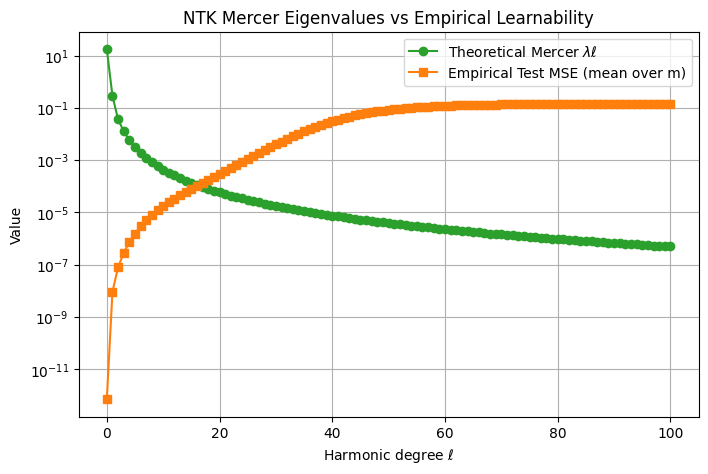

In [ ]:
# Mse vs harmonics degree (l)
L_vals = max(l for (l,m) in lm_list)

test_mse_by_l = []
train_mse_by_l = []
for l in range(L_vals+1):
    test_mse_l = [test_mse[mode_indices[(l,m)]] for m in range(-l,l+1)]
    test_mse_by_l.append(jnp.mean(jnp.array(test_mse_l)))
    train_mse_l = [train_mse[mode_indices[(l,m)]] for m in range(-l,l+1)]
    train_mse_by_l.append( jnp.mean(jnp.array(train_mse_l)) )

plt.figure(figsize=(8,5))
plt.semilogy(lambda_ells, 'o-', label=r"Theoretical Mercer $\lambda \ell$", c='C2')
plt.semilogy(test_mse_by_l, 's-', label="Empirical Test MSE (mean over m)", c='C1')
plt.xlabel(r"Harmonic degree $\ell$")
plt.ylabel("Value")
plt.title("NTK Mercer Eigenvalues vs Empirical Learnability")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Run single ntk setup
def run_ntk_sphere_single(
    W_std=1.0,
    b_std=0.0,
    N_train=2000,
    N_test=5000,
    L_max=50,
    reg="auto",              # or a float
    selected_lm=None,        # list of (l,m) pairs to keep predictions for
    trainable=("W", "b"),
):
    """
    Run NTK spectral + spherical harmonic prediction experiment on S^2.
    """

    # Sample points on S^2 using Fibonacci sphere
    X_train, theta_train, phi_train = fibonacci_sphere(N_train)
    X_test,  theta_test,  phi_test  = fibonacci_sphere(N_test)

    X_train = jnp.array(X_train, dtype=jnp.float32)
    X_test  = jnp.array(X_test,  dtype=jnp.float32)

    # Build NTK network
    init_fn, apply_fn, kernel_fn = stax.serial(
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable),
        stax.Relu(),
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable),
    )
    kernel_fn = nt.batch(kernel_fn, device_count=-1)

    # Compute eigenvalues of NTK on training points
    K_ntk_full = jnp.array(kernel_fn(X_train, X_train, "ntk"))
    eigvals = jnp.sort(jnp.linalg.eigvalsh(K_ntk_full))[::-1]

    # Kernel ridge regression setup
    K_train = K_ntk_full
    K_test_train = jnp.array(kernel_fn(X_test, X_train, "ntk"))

    if reg == "auto":
        reg_value = float(eigvals[0]) / 300000.0
    else:
        reg_value = float(reg)

    K_reg = K_train + reg_value * jnp.eye(N_train)

    # Enumerate spherical harmonic modes (l,m)
    lm_list = make_lm_list(L_max)
    mode_indices = {(l, m): i for i, (l, m) in enumerate(lm_list)}

    if selected_lm is None:
        selected_lm = [(0,0), (1,0), (2,-1), (3,2),
                       (4,0), (5,4), (6,-3), (7,5),
                       (10,2), (12,3)]

    train_mse = []
    test_mse  = []
    predictions = {}

    # Loop over modes, do kernel regression for each Y_l^m
    for (l, m) in tqdm(lm_list, desc="S^2 modes"):

        # SciPy sph_harm is NumPy-based, so use np arrays
        y_train_np = real_Ylm(l, m,
                              np.array(theta_train),
                              np.array(phi_train))
        y_test_np  = real_Ylm(l, m,
                              np.array(theta_test),
                              np.array(phi_test))

        y_train = jnp.array(y_train_np, dtype=jnp.float32)
        y_test  = jnp.array(y_test_np,  dtype=jnp.float32)

        alpha = jnp.linalg.solve(K_reg, y_train)

        y_pred_train = K_train @ alpha
        y_pred_test  = K_test_train @ alpha

        train_mse.append(jnp.mean((y_pred_train - y_train)**2))
        test_mse.append(jnp.mean((y_pred_test  - y_test)**2))

        if (l, m) in selected_lm:
            predictions[(l, m)] = dict(
                true=y_test,
                pred=y_pred_test,
                theta=theta_test,
                phi=phi_test,
            )

    train_mse = jnp.array(train_mse)
    test_mse  = jnp.array(test_mse)

    # Aggregate test MSE by degree l
    L_vals = L_max
    mse_by_l = []
    for l in range(L_vals + 1):
        idxs = [mode_indices[(l, m)] for m in range(-l, l+1)]
        mse_l = test_mse[jnp.array(idxs)]
        mse_by_l.append(jnp.mean(mse_l))

    mse_by_l = jnp.array(mse_by_l)

    # Package result object
    result = dict(
        W_std=W_std,
        b_std=b_std,
        eigvals=eigvals,
        train_mse=train_mse,   # per (l,m)
        test_mse=test_mse,     # per (l,m)
        mse_by_l=mse_by_l,     # per l
        lm_list=lm_list,
        mode_indices=mode_indices,
        predictions=predictions,
        selected_lm=selected_lm,
        reg=reg_value,
        trainable=trainable,
        N_train=N_train,
        N_test=N_test,
        L_max=L_max,
    )
    return result


def run_ntk_sphere_multiple(config_list):
    results = []
    for cfg in tqdm(config_list, desc=r"All $S^2$ configs"):
        res = run_ntk_sphere_single(**cfg)
        results.append(res)
    return results

def plot_all_eigenspectra_sphere(all_results):
    plt.figure(figsize=(8,5))

    for res in all_results:
        trainable = "both" if res['trainable']==("W","b") else "custom"
        label = f"W={res['W_std']}, b={res['b_std']}"
        plt.plot(res['eigvals'], label=label)

    plt.yscale("log")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title(r"NTK Eigenvalue Spectra on $S^2$ (multiple configs)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_all_mse_curves_sphere(all_results):
    plt.figure(figsize=(8,5))

    for res in all_results:
        label = f"W={res['W_std']}, b={res['b_std']}"
        plt.semilogy(res['mse_by_l'], 'o-', label=label)

    plt.xlabel(r"Spherical harmonic degree $\ell$")
    plt.ylabel("Mean test MSE (log scale)")
    plt.title(r"Prediction Error vs Degree $\ell$ ($S^2$)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compute_l_capacity(res, thresholds):
    mse_by_l = res['mse_by_l']
    return jnp.array([jnp.sum(mse_by_l < t) for t in thresholds])

def plot_l_capacity_multiple_sphere(all_results,
                                    thresholds=jnp.logspace(-6, 0, 50)):
    plt.figure(figsize=(8,6))

    for res in all_results:
        label = f"W={res['W_std']}, b={res['b_std']}"
        cap = compute_l_capacity(res, thresholds)
        plt.plot(thresholds, cap, label=label)

    plt.xscale("log")
    plt.xlabel("MSE threshold")
    plt.ylabel(r"# of degrees $\ell$ with MSE below threshold")
    plt.title("Learnable Spherical-Harmonic Bandwidth vs MSE Threshold")
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compute_cutoff_frequency(res, threshold):
    """
    Return the maximum harmonic k such that test_mse[k] < threshold.
    Returns -1 if none are learnable.
    """
    test_mse = res['test_mse']
    below = jnp.where(test_mse < threshold)[0]
    return int(below.max()) if len(below) > 0 else -1

def plot_conditioning_before_after_sphere(all_results):
    plt.figure(figsize=(8,5))

    for i, res in enumerate(all_results):
        eig = res['eigvals']
        eig_pos = eig[eig > 0]

        if len(eig_pos) == 0:
            continue

        lam_max = float(eig_pos[0])
        lam_min = float(eig_pos[-1])
        reg     = float(res['reg'])

        cond_before = lam_max / lam_min
        cond_after  = (lam_max + reg) / (lam_min + reg)

        label = f"W={res['W_std']}, b={res['b_std']}, reg={reg:.2e}"

        plt.scatter(i - 0.1, cond_before, color="blue",
                    label="before" if i==0 else None)
        plt.scatter(i + 0.1, cond_after,  color="red",
                    label="after"  if i==0 else None)

    plt.yscale("log")
    plt.xlabel("Trial index")
    plt.ylabel("Condition number")
    plt.title(r"Conditioning Before vs After Regularization ($S^2$ NTK)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

All S^2 configs: 100%|██████████| 7/7 [11:09<00:00, 95.71s/it]


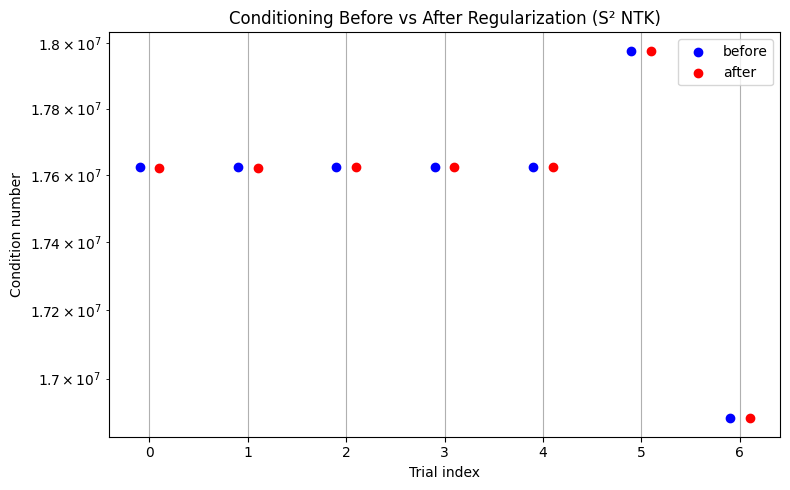

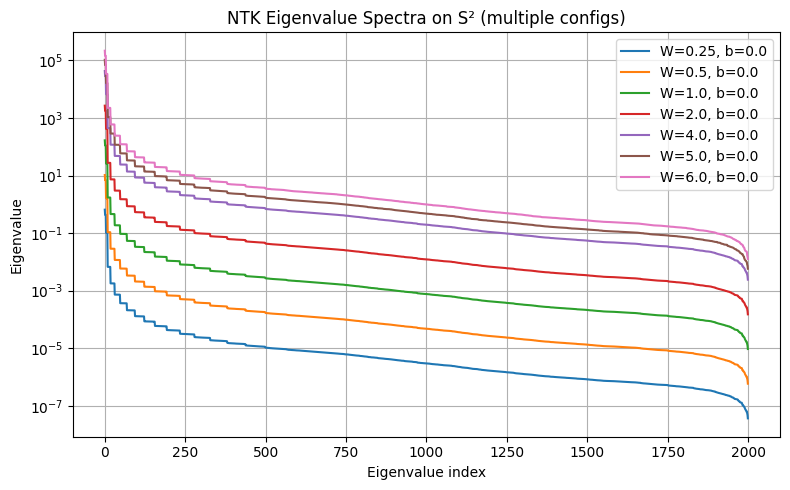

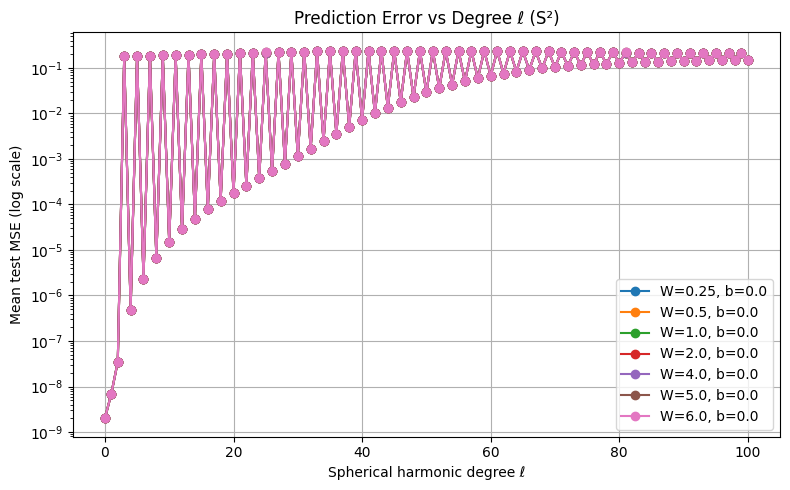

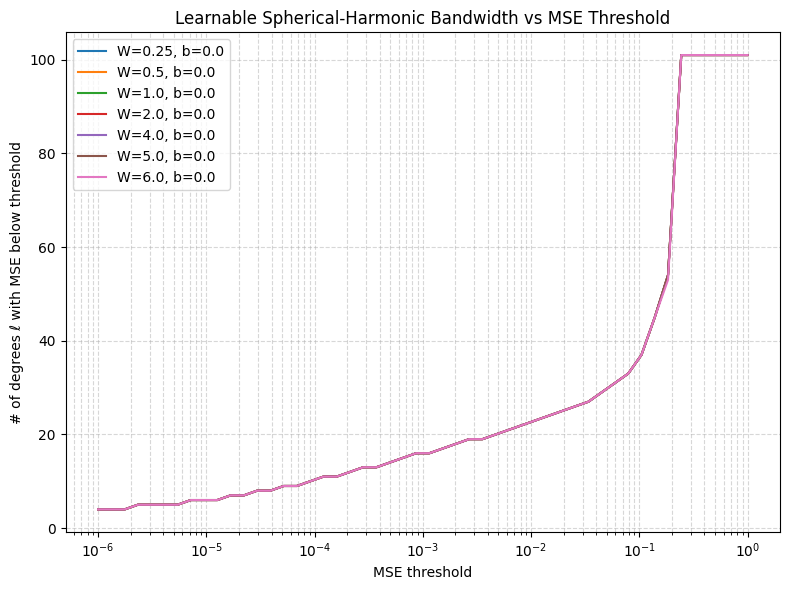

In [ ]:
configs_W_sphere = [
    dict(W_std=0.25, b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=0.5,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=1.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=2.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=4.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=5.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
]

all_results_sphere = run_ntk_sphere_multiple(configs_W_sphere)

plot_conditioning_before_after_sphere(all_results_sphere)
plot_all_eigenspectra_sphere(all_results_sphere)
plot_all_mse_curves_sphere(all_results_sphere)
plot_l_capacity_multiple_sphere(all_results_sphere)


All S^2 configs: 100%|██████████| 4/4 [06:06<00:00, 91.63s/it]


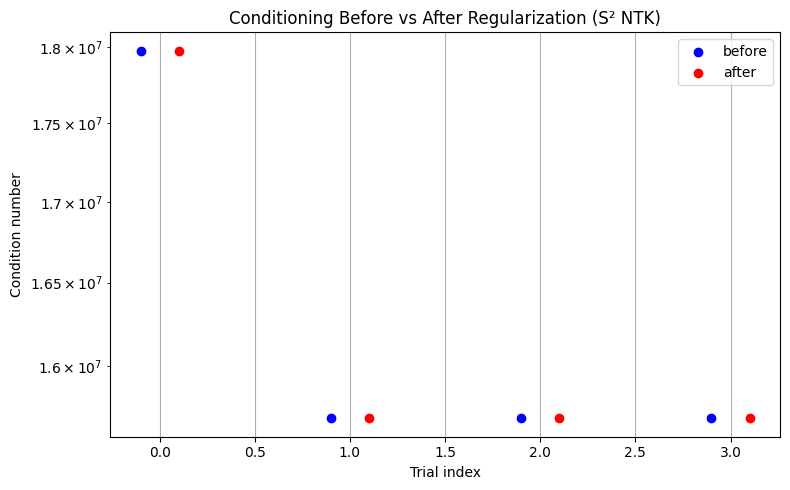

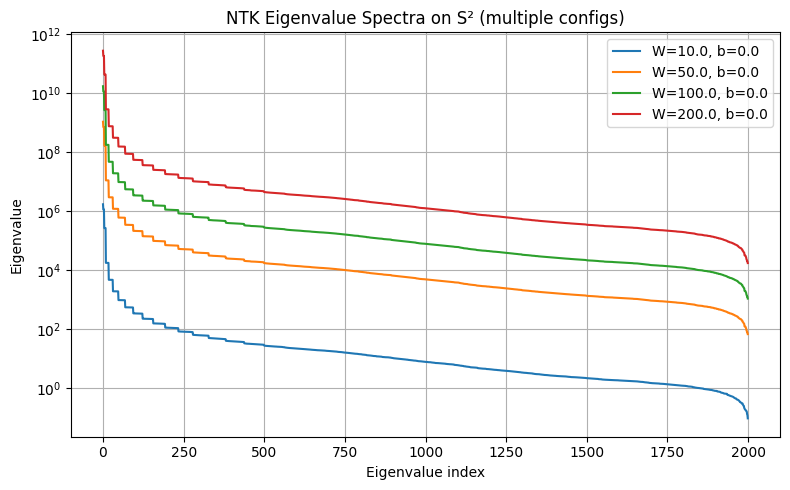

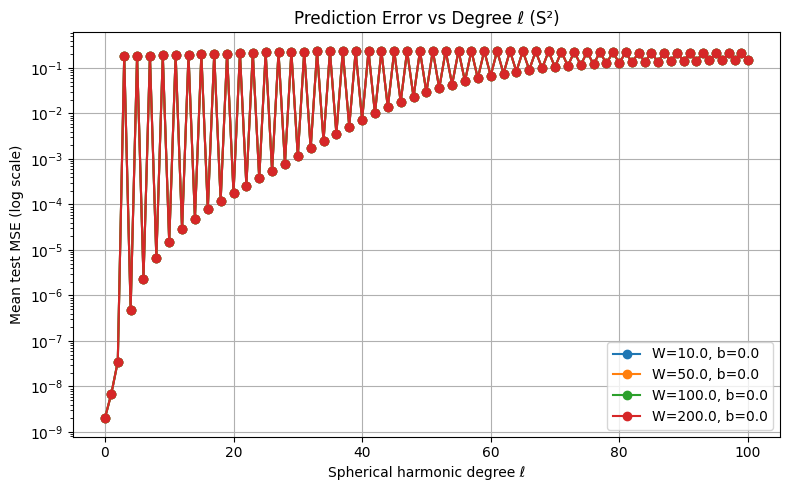

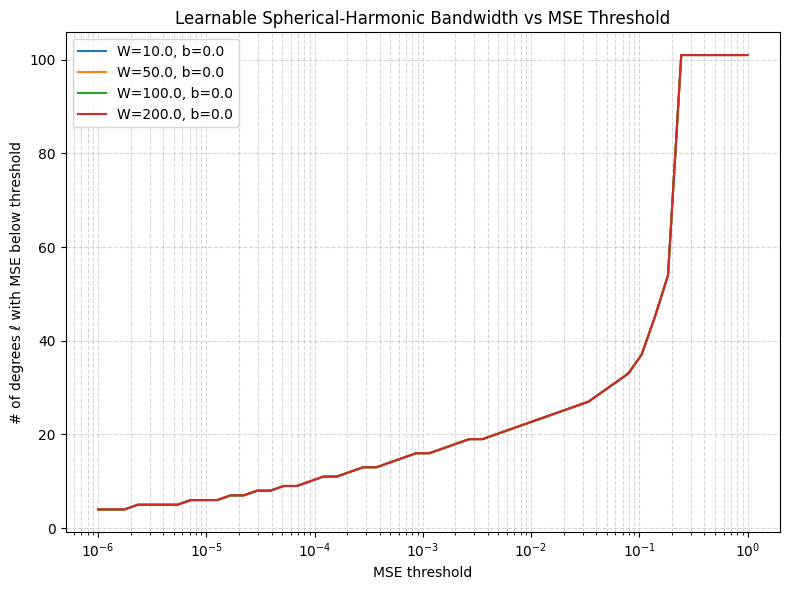

In [ ]:
configs_W_sphere = [
    dict(W_std=10.0, b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=50.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=100.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=200.0,  b_std=0.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
]

all_results_sphere = run_ntk_sphere_multiple(configs_W_sphere)

plot_conditioning_before_after_sphere(all_results_sphere)
plot_all_eigenspectra_sphere(all_results_sphere)
plot_all_mse_curves_sphere(all_results_sphere)
plot_l_capacity_multiple_sphere(all_results_sphere)

All S^2 configs: 100%|██████████| 8/8 [12:34<00:00, 94.33s/it]


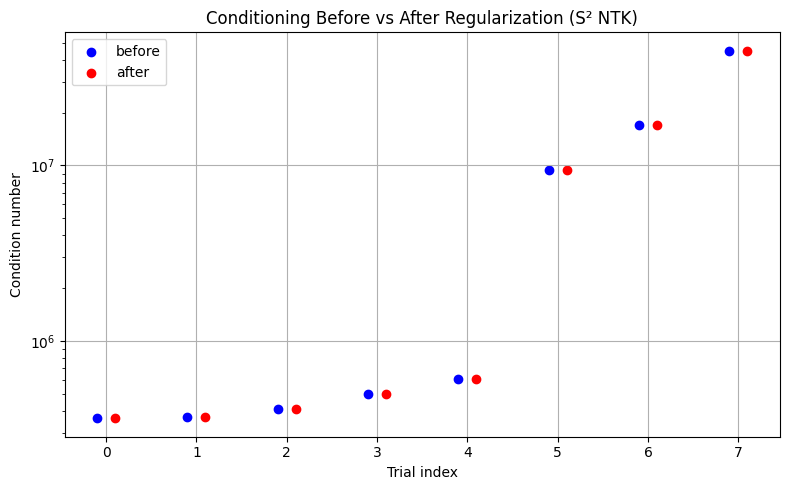

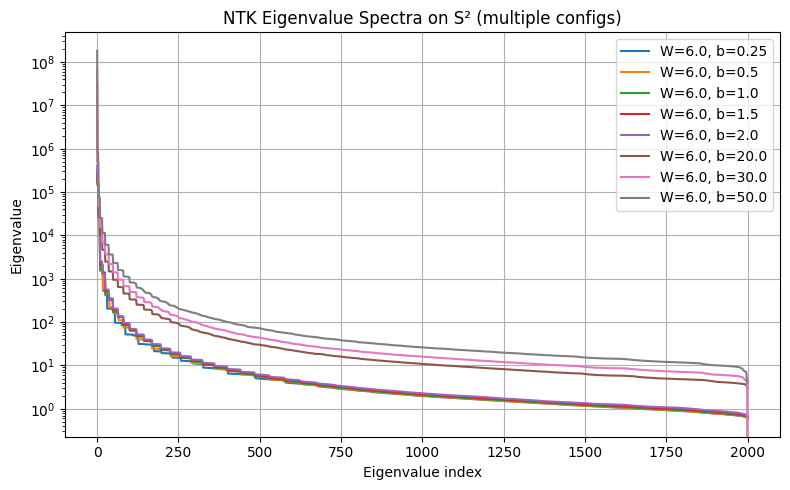

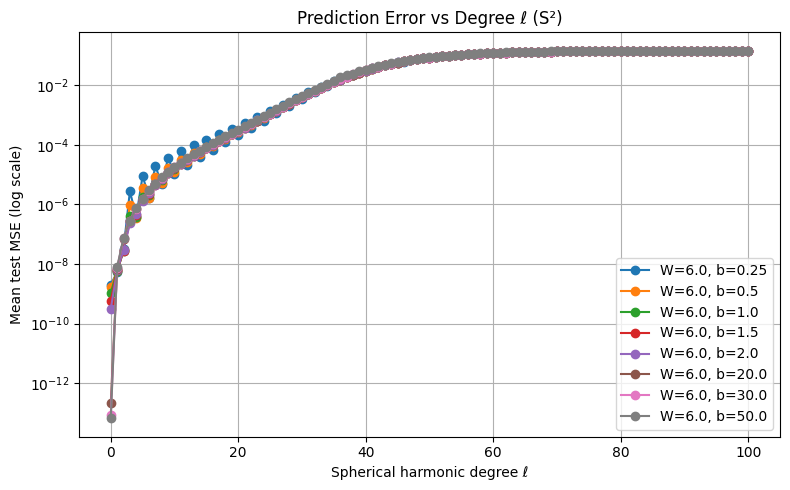

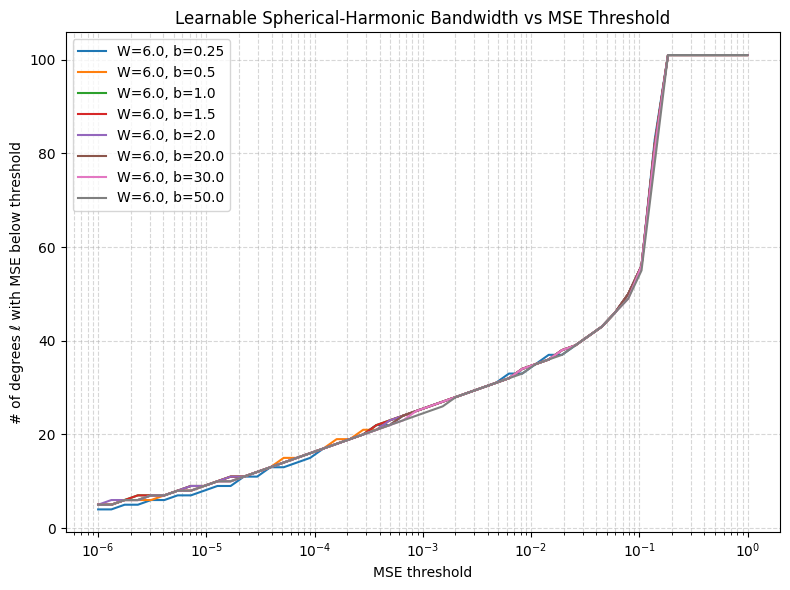

In [9]:
configs_b_sphere = [
    dict(W_std=6.0,  b_std=0.25, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=0.5, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=1.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=1.5, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=2.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=20.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=30.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=50.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
]

all_results_sphere = run_ntk_sphere_multiple(configs_b_sphere)

plot_conditioning_before_after_sphere(all_results_sphere)
plot_all_eigenspectra_sphere(all_results_sphere)
plot_all_mse_curves_sphere(all_results_sphere)
plot_l_capacity_multiple_sphere(all_results_sphere)

All S^2 configs: 100%|██████████| 8/8 [12:22<00:00, 92.81s/it]


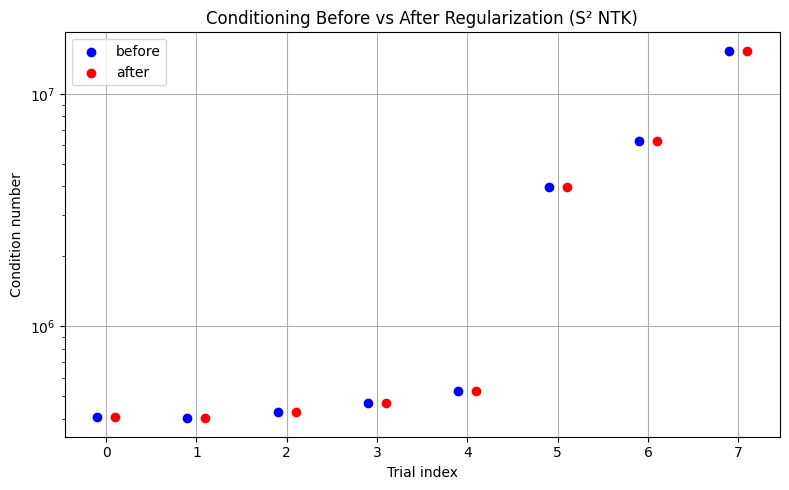

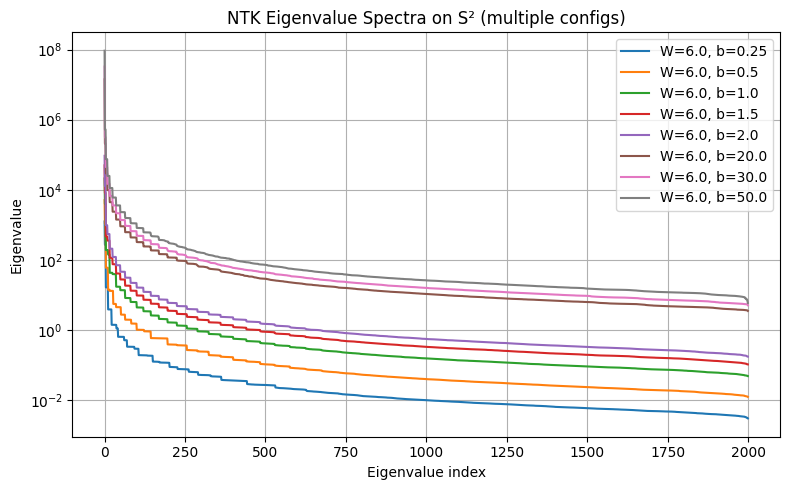

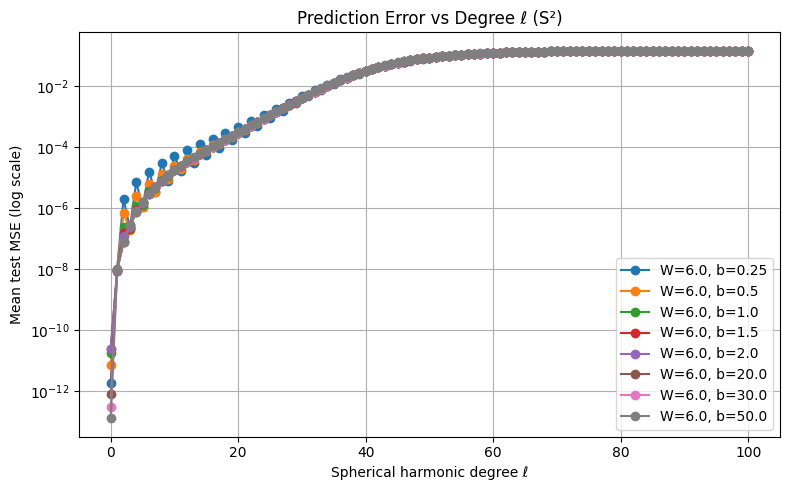

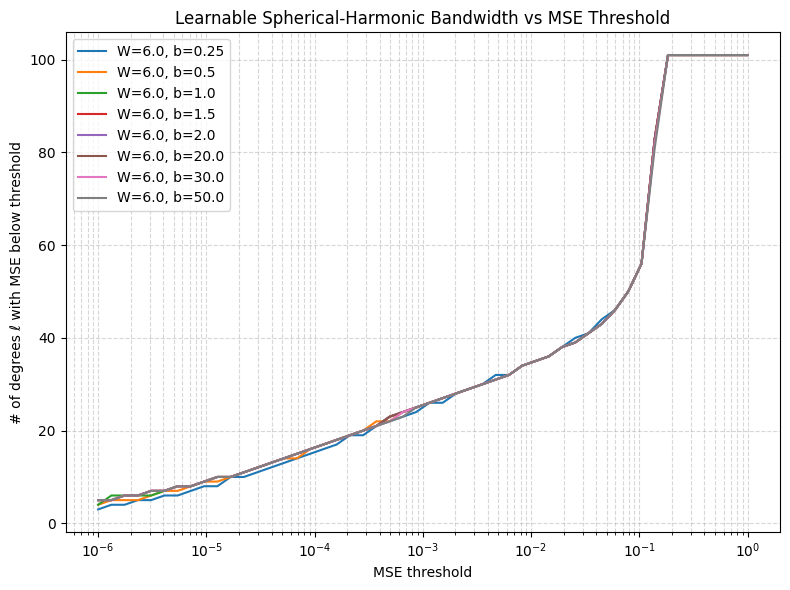

In [10]:
configs_b_sphere = [
    dict(W_std=6.0,  b_std=0.25, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=0.5, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=1.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=1.5, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=2.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=20.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=30.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
    dict(W_std=6.0,  b_std=50.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b")),
]

all_results_sphere = run_ntk_sphere_multiple(configs_b_sphere)

plot_conditioning_before_after_sphere(all_results_sphere)
plot_all_eigenspectra_sphere(all_results_sphere)
plot_all_mse_curves_sphere(all_results_sphere)
plot_l_capacity_multiple_sphere(all_results_sphere)

In [ ]:
def split_groups(all_results):
    full = []
    bias = []
    for res in all_results:
        if res["trainable"] == ("W","b"):
            full.append(res)
        elif res["trainable"] == ("b",):
            bias.append(res)
        else:
            print("WARNING: unknown trainable=", res["trainable"])
    return full, bias

def plot_all_eigenspectra_sphere_grouped(all_results):
    full, bias = split_groups(all_results)

    plt.figure(figsize=(10,5))

    # full NTK curves
    for res in full:
        label = f"FULL: b={res['b_std']}"
        plt.plot(res['eigvals'], label=label, alpha=0.8)

    # bias-only curves
    for res in bias:
        label = f"BIAS: b={res['b_std']}"
        plt.plot(res['eigvals'], '--', label=label, alpha=0.8)

    plt.yscale("log")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("NTK Eigenvalue Spectra on S² (Full vs Bias-only)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_all_mse_curves_sphere_grouped(all_results):
    full, bias = split_groups(all_results)

    plt.figure(figsize=(10,5))

    # full NTK curves
    for res in full:
        label = f"FULL: b={res['b_std']}"
        plt.semilogy(res['mse_by_l'], 'o-', label=label)

    # bias-only NTK curves
    for res in bias:
        label = f"BIAS: b={res['b_std']}"
        plt.semilogy(res['mse_by_l'], 's--', label=label)

    plt.xlabel(r"Degree $\ell$")
    plt.ylabel("Mean Test MSE (log scale)")
    plt.title(r"Test Error vs Spherical Harmonic Degree $\ell$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_all_mse_curves_sphere_grouped(all_results):
    full, bias = split_groups(all_results)

    plt.figure(figsize=(10,5))

    # full NTK curves
    for res in full:
        label = f"FULL: b={res['b_std']}"
        plt.semilogy(res['mse_by_l'], 'o-', label=label)

    # bias-only NTK curves
    for res in bias:
        label = f"BIAS: b={res['b_std']}"
        plt.semilogy(res['mse_by_l'], 's--', label=label)

    plt.xlabel(r"Degree $\ell$")
    plt.ylabel("Mean Test MSE (log scale)")
    plt.title("Test Error vs Spherical Harmonic Degree ℓ")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_l_capacity_multiple_sphere_grouped(all_results,
                                            thresholds=jnp.logspace(-6, 0, 50)):

    full, bias = split_groups(all_results)

    plt.figure(figsize=(10,5))

    # full NTK group
    for res in full:
        label = f"FULL: b={res['b_std']}"
        cap = jnp.array([jnp.sum(res['mse_by_l'] < t) for t in thresholds])
        plt.plot(thresholds, cap, label=label)

    # bias-only NTK group
    for res in bias:
        label = f"BIAS: b={res['b_std']}"
        cap = jnp.array([jnp.sum(res['mse_by_l'] < t) for t in thresholds])
        plt.plot(thresholds, cap, '--', label=label)

    plt.xscale("log")
    plt.xlabel("MSE threshold")
    plt.ylabel(r"# of degrees $\ell$ learned")
    plt.title("Learnable Spherical-Harmonic Bandwidth (Full vs Bias-only)")
    plt.grid(True, which='both', ls='--')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_mse_difference_full_vs_bias(all_results):
    full, bias = split_groups(all_results)

    # index by b_std for easy alignment
    full_dict = {res['b_std']: res for res in full}
    bias_dict = {res['b_std']: res for res in bias}

    common_b = sorted(set(full_dict.keys()) & set(bias_dict.keys()))

    plt.figure(figsize=(10,5))

    for b in common_b:
        mse_full = full_dict[b]['mse_by_l']
        mse_bias = bias_dict[b]['mse_by_l']

        diff = jnp.abs(mse_bias - mse_full)   # positive = bias-only worse

        plt.semilogy(diff, label=f"b_std={b}")

    plt.axhline(0, color='black', lw=1)
    plt.xlabel(r"Degree $\ell$")
    plt.ylabel("Δ MSE = MSE_bias - MSE_full")
    plt.title("Difference Between Full NTK and Bias-only NTK")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


All S^2 configs: 100%|██████████| 14/14 [21:47<00:00, 93.36s/it]


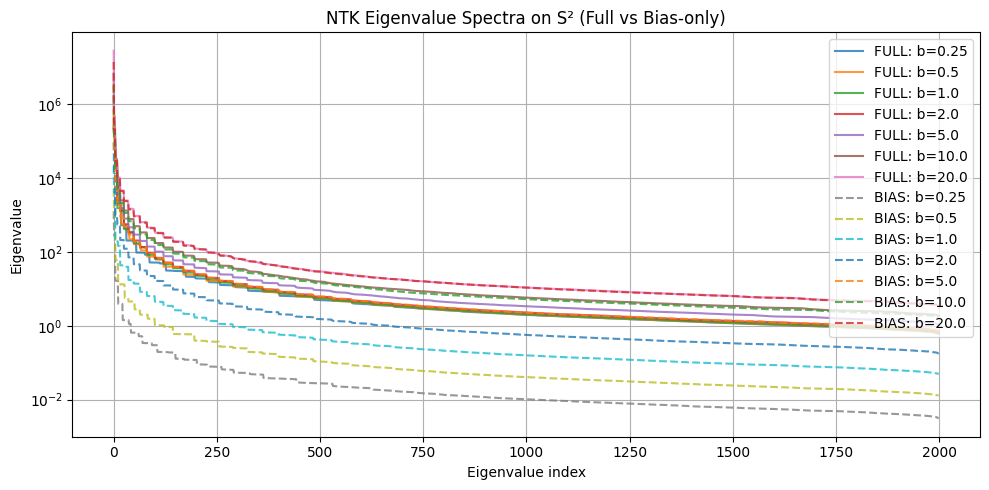

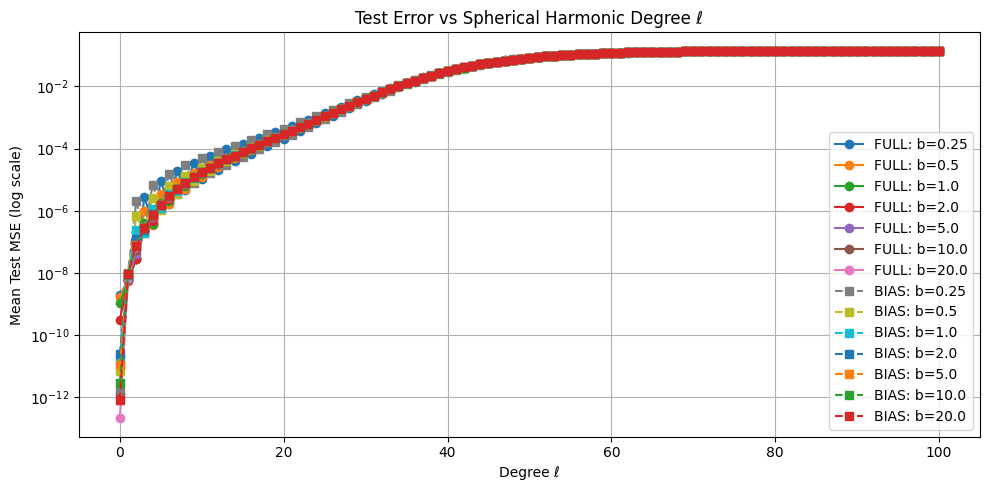

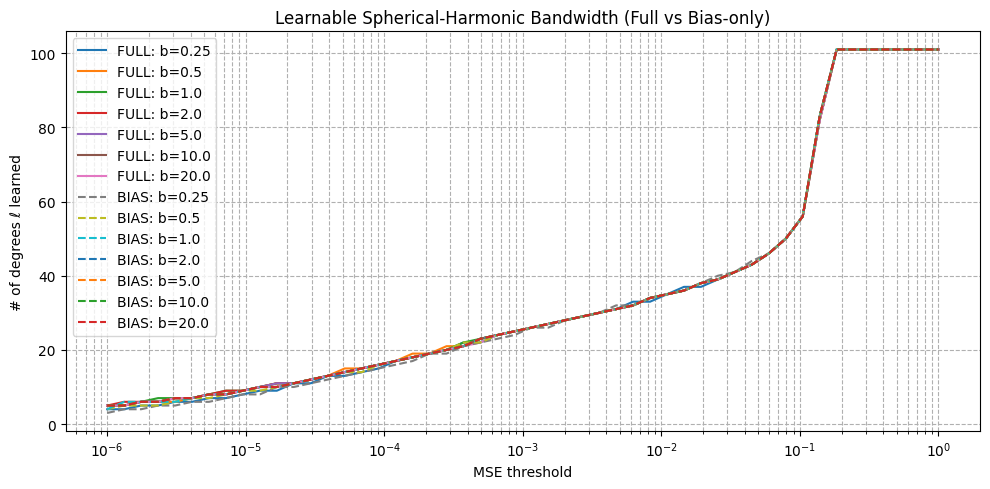

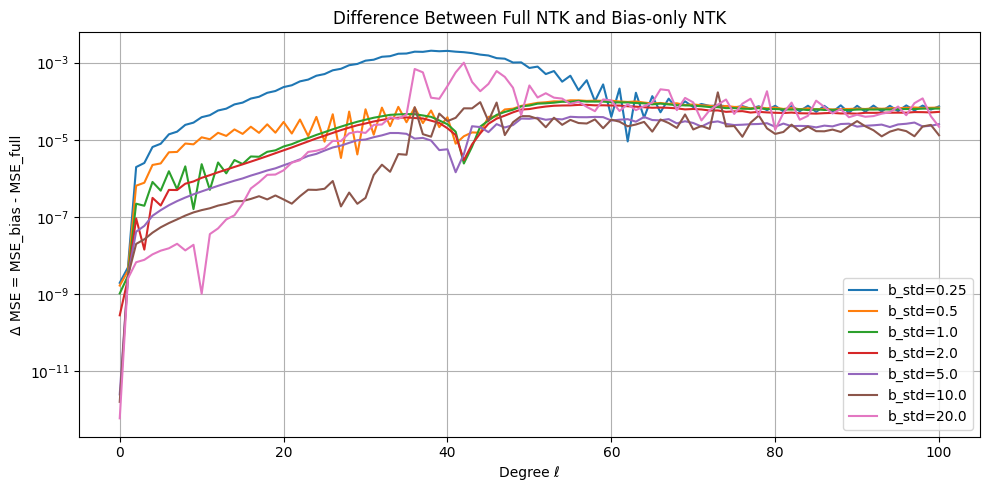

In [12]:
configs_sphere = [
    dict(W_std=6.0,  b_std=0.25, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=0.5, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=1.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=2.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=5.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=10.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=20.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000),
    dict(W_std=6.0,  b_std=0.25, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
    dict(W_std=6.0,  b_std=0.5, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
    dict(W_std=6.0,  b_std=1.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
    dict(W_std=6.0,  b_std=2.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
    dict(W_std=6.0,  b_std=5.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
    dict(W_std=6.0,  b_std=10.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
    dict(W_std=6.0,  b_std=20.0, reg=1e-12, L_max=100, N_train=2000, N_test=5000, trainable=("b",)),
]

all_results_sphere = run_ntk_sphere_multiple(configs_sphere)

plot_all_eigenspectra_sphere_grouped(all_results_sphere)
plot_all_mse_curves_sphere_grouped(all_results_sphere)
plot_l_capacity_multiple_sphere_grouped(all_results_sphere)
plot_mse_difference_full_vs_bias(all_results_sphere)

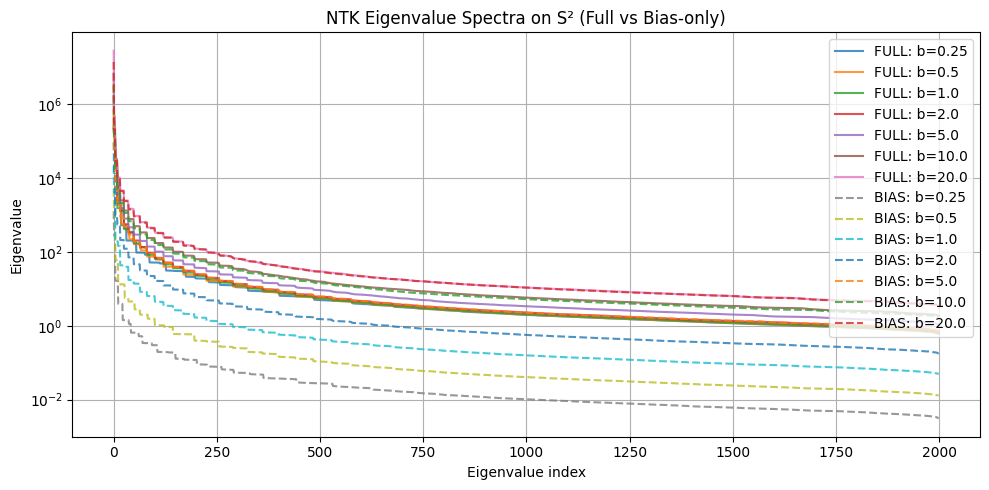

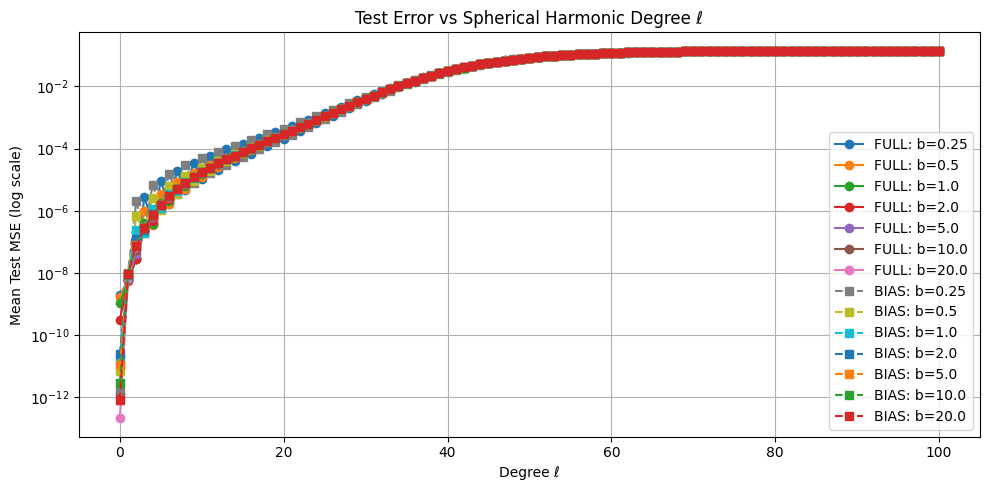

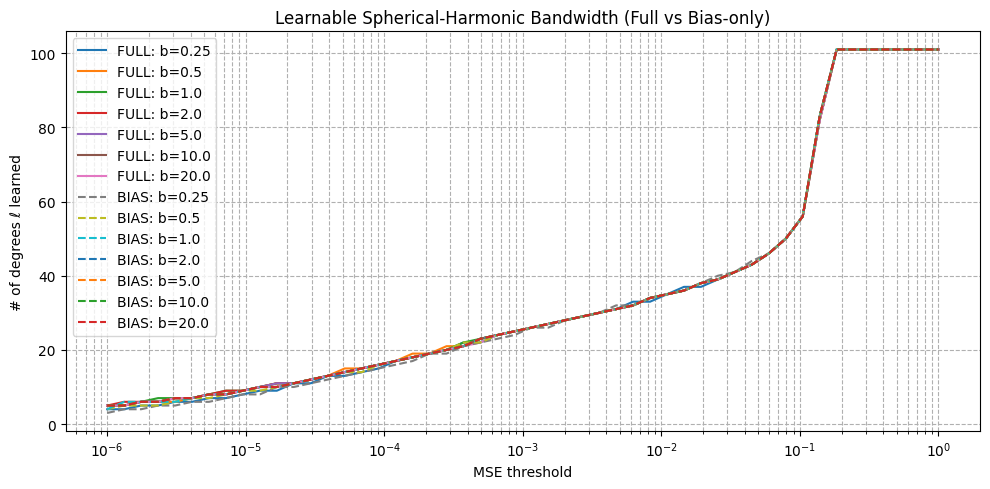

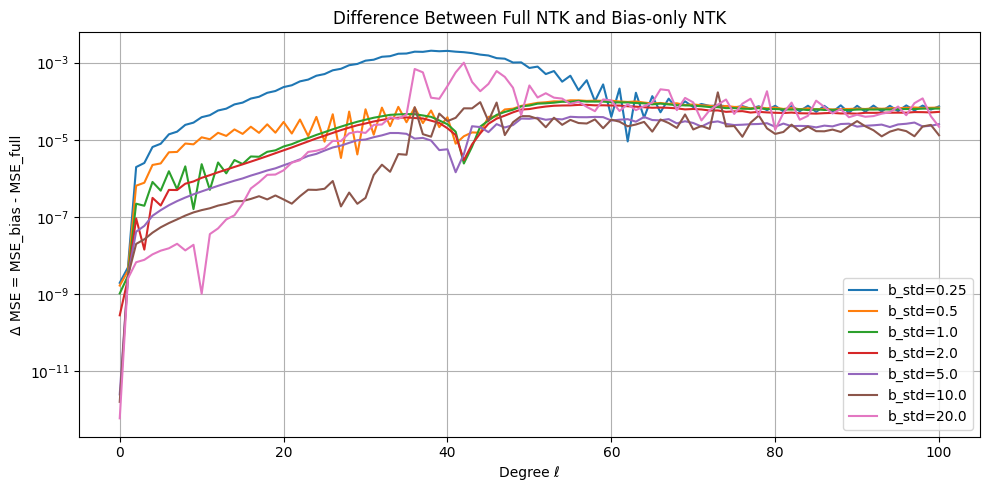

In [13]:
plot_all_eigenspectra_sphere_grouped(all_results_sphere)
plot_all_mse_curves_sphere_grouped(all_results_sphere)
plot_l_capacity_multiple_sphere_grouped(all_results_sphere)
plot_mse_difference_full_vs_bias(all_results_sphere)